In [1]:
import os, sys
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import copy

from util import construct_graph, sparse_mx_to_torch_sparse_tensor  # from their code
from model import CoGCN  # from their code



In [2]:
def stratified_split(y: np.ndarray, train_ratio=0.01, val_ratio=0.10, seed=0):
    """
    Stratified split for semi-supervised node classification.

    - Ensures each class contributes proportionally.
    - Ensures at least 1 labeled sample per class in train and val.

    Returns:
      train_idx, val_idx, test_idx (1D int arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    classes = np.unique(y)

    train_idx, val_idx, test_idx = [], [], []
    for c in classes:
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n = len(idx)

        n_train = max(1, int(round(train_ratio * n)))
        n_val   = max(1, int(round(val_ratio * n)))

        train_idx.append(idx[:n_train])
        val_idx.append(idx[n_train:n_train + n_val])
        test_idx.append(idx[n_train + n_val:])

    train_idx = np.concatenate(train_idx)
    val_idx   = np.concatenate(val_idx)
    test_idx  = np.concatenate(test_idx)

    rng.shuffle(train_idx); rng.shuffle(val_idx); rng.shuffle(test_idx)
    return train_idx, val_idx, test_idx

Toy

In [3]:
# def make_multiview_toy(
#     n=3000,
#     n_classes=6,
#     dims=(128, 32, 256),
#     latent_dim=8,
#     class_separation=3.0,
#     cluster_std=0.8,
#     snr=(1.5, 0.8, 0.2),          # view quality: higher is cleaner, lower is noisier
#     adv_view=2,                   # which view to corrupt adversarially (None disables)
#     adv_frac=0.25,                # fraction of nodes to corrupt in that view
#     rotate_view=1,                # rotate one view to reduce trivial alignment (None disables)
#     seed=0,
#     train_ratio=0.01,
#     val_ratio=0.10,
# ):
#     """
#     Create a multi-view toy dataset.

#     Returns:
#       feats_np : list[np.ndarray]  -> [X0, X1, ...], each shape (n, d_v)
#       y        : np.ndarray        -> labels, shape (n,)
#       splits   : (train_idx, val_idx, test_idx)

#     How data is created:
#       1) Create n_classes centers in a latent space (latent_dim).
#       2) Sample each node's latent vector around its class center.
#       3) For each view v:
#          - Randomly project latent vectors to d_v dimensions.
#          - Add Gaussian noise.
#          - Mix signal and noise using snr[v] (controls view difficulty).
#       4) Optional adversarial corruption on one view:
#          - For adv_frac*n nodes, replace features with features from a node
#            of a different class => encourages wrong neighborhoods in kNN graph.
#       5) Create stratified train/val/test indices for semi-supervised learning.
#     """
#     rng = np.random.default_rng(seed)

#     # (1) latent class centers: spread them out by class_separation
#     centers = rng.normal(size=(n_classes, latent_dim)).astype(np.float32) * class_separation

#     # (2) labels + latent vectors
#     y = rng.integers(0, n_classes, size=n, endpoint=False).astype(int)
#     Z = centers[y] + rng.normal(scale=cluster_std, size=(n, latent_dim)).astype(np.float32)

#     feats_np = []

#     # (3) generate each view's features
#     for v, d in enumerate(dims):
#         # random linear map from latent -> view space
#         W = rng.normal(size=(latent_dim, d)).astype(np.float32)
#         signal = Z @ W  # (n, d)

#         # normalize so SNR behaves consistently across views/dims
#         signal = signal / (signal.std() + 1e-6)

#         noise = rng.normal(size=(n, d)).astype(np.float32)
#         noise = noise / (noise.std() + 1e-6)

#         # combine: view-specific SNR controls informativeness
#         Xv = snr[v] * signal + 1.0 * noise

#         # optional: rotate one view to reduce trivial similarity between views
#         if rotate_view is not None and v == rotate_view:
#             R = rng.normal(size=(d, d)).astype(np.float32)
#             U, _, Vt = np.linalg.svd(R, full_matrices=False)
#             Xv = Xv @ (U @ Vt)

#         feats_np.append(Xv.astype(np.float32))

#     # (4) adversarial corruption: swap features across different classes in one view
#     if adv_view is not None and 0 <= adv_view < len(feats_np) and adv_frac > 0:
#         Xadv = feats_np[adv_view].copy()
#         m = int(round(adv_frac * n))

#         idx_a = rng.choice(n, size=m, replace=False)
#         idx_b = rng.choice(n, size=m, replace=False)

#         # force swaps to be across different classes (maximally misleading)
#         for i in range(m):
#             if y[idx_a[i]] == y[idx_b[i]]:
#                 candidates = np.where(y != y[idx_a[i]])[0]
#                 idx_b[i] = rng.choice(candidates)

#         Xadv[idx_a] = feats_np[adv_view][idx_b]
#         feats_np[adv_view] = Xadv

#     # (5) semi-supervised splits
#     train_idx, val_idx, test_idx = stratified_split(
#         y, train_ratio=train_ratio, val_ratio=val_ratio, seed=seed
#     )

#     return feats_np, y, (train_idx, val_idx, test_idx)


In [4]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # feats_np: list of np arrays, each (n, d_v)
# # y: np int labels shape (n,)
# # splits: train_idx, val_idx, test_idx
# feats_np, y, (train_idx, val_idx, test_idx) = make_multiview_toy(seed=42)

# n_view = len(feats_np)
# n_class = int(np.max(y) + 1)


In [5]:
# print("Views:", [f.shape for f in feats_np])
# print("Label counts:", np.bincount(y))
# print("Splits:", len(train_idx), len(val_idx), len(test_idx))

In [6]:
# # --- Build one adjacency per view using paper function ---
# adjs = []
# for v in range(n_view):
#     A = construct_graph(feats_np[v], targets=y, k=10, metric="euclidean")  # scipy sparse
#     adjs.append(sparse_mx_to_torch_sparse_tensor(A).to(device))            # torch sparse

In [7]:

# # --- Move features/labels/splits to torch ---
# feats = [torch.FloatTensor(X).to(device) for X in feats_np]
# labels = torch.LongTensor(y).to(device)

# train_idx = torch.LongTensor(train_idx).to(device)
# val_idx   = torch.LongTensor(val_idx).to(device)
# test_idx  = torch.LongTensor(test_idx).to(device)

# print("Views:", [tuple(f.shape) for f in feats])
# print("Classes:", n_class, "Train/Val/Test:", len(train_idx), len(val_idx), len(test_idx))

Cora

In [8]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# import numpy as np
# import scipy.sparse as sp
# import torch
# from torch_geometric.datasets import Planetoid

# from util import construct_graph, sparse_mx_to_torch_sparse_tensor  # paper util.py

# # ----------------------------
# # Load Cora (PyG)
# # ----------------------------
# dataset = Planetoid(root="./data", name="Cora")
# data = dataset[0]

# X = data.x.cpu().numpy().astype(np.float32)          # (N, 1433)
# y = data.y.cpu().numpy().astype(int)                # (N,)
# N, D = X.shape
# n_class = int(y.max() + 1)

# train_idx = np.where(data.train_mask.cpu().numpy())[0]
# val_idx   = np.where(data.val_mask.cpu().numpy())[0]
# test_idx  = np.where(data.test_mask.cpu().numpy())[0]

# print("X:", X.shape, "classes:", n_class)
# print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))

# # ----------------------------
# # Build citation adjacency (view graph 1)
# #   - undirected
# #   - add self-loops
# #   - row-normalize (matches paper normalize() behavior)
# # ----------------------------
# edge_index = data.edge_index.cpu().numpy()
# row, col = edge_index[0], edge_index[1]

# A = sp.coo_matrix((np.ones(len(row), dtype=np.float32), (row, col)), shape=(N, N)).tocsr()
# A = A + A.T
# A[A > 1] = 1
# A = A + sp.eye(N, dtype=np.float32)

# rowsum = np.array(A.sum(1)).flatten()
# r_inv = np.power(rowsum, -1, where=rowsum != 0)
# r_inv[~np.isfinite(r_inv)] = 0.0
# A_cite_norm = sp.diags(r_inv).dot(A).tocoo().astype(np.float32)

# # ----------------------------
# # Define 2 "views"
# #   View 0: original node features X
# #   View 1: one-step structural smoothing A_norm @ X
# # ----------------------------
# X0 = X
# X1 = (A_cite_norm.tocsr() @ X0).astype(np.float32)

# # ----------------------------
# # Define 2 adjacency matrices (graphs)
# #   Adj0: kNN graph built from X0 (paper construct_graph)
# #   Adj1: citation graph from PyG (A_cite_norm)
# # ----------------------------
# Adj0 = construct_graph(X0, targets=y, k=10, metric="cosine")  # returns normalized sparse
# Adj1 = A_cite_norm                                           # already normalized

# # ----------------------------
# # Convert to torch tensors for training
# # ----------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# feats = [
#     torch.FloatTensor(X0).to(device),
#     torch.FloatTensor(X1).to(device),
# ]

# adjs = [
#     sparse_mx_to_torch_sparse_tensor(Adj0).to(device),
#     sparse_mx_to_torch_sparse_tensor(Adj1).to(device),
# ]

# labels = torch.LongTensor(y).to(device)

# train_idx = torch.LongTensor(train_idx).to(device)
# val_idx   = torch.LongTensor(val_idx).to(device)
# test_idx  = torch.LongTensor(test_idx).to(device)

# n_view = 2
# n_feat = [feats[0].shape[1], feats[1].shape[1]]

# print("n_view:", n_view)
# print("n_feat:", n_feat)


EAV: EEG + Audio Views


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

eeg = torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/eeg_sub1_features.pt", map_location="cpu")
aud = torch.load("/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/Data/audio_sub1_features.pt", map_location="cpu")


In [11]:
# --- Align train/test splits across views ---
X0_train = eeg['train'].float()
X0_test  = eeg['test'].float()
X1_train = aud['train'].float()
X1_test  = aud['test'].float()

y_train = eeg['y_train'].long()
y_test  = eeg['y_test'].long()

In [12]:
assert X0_train.shape[0] == X1_train.shape[0], 'Train sizes must match across views'
assert X0_test.shape[0] == X1_test.shape[0], 'Test sizes must match across views'
assert y_train.shape[0] == X0_train.shape[0], 'Train labels must match train features'
assert y_test.shape[0] == X0_test.shape[0], 'Test labels must match test features'

In [13]:
# Concatenate to get full graph (train first, test second)
X0 = torch.cat([X0_train, X0_test], dim=0).numpy().astype(np.float32)
X1 = torch.cat([X1_train, X1_test], dim=0).numpy().astype(np.float32)
y  = torch.cat([y_train, y_test], dim=0).numpy().astype(int)

In [14]:
n_train = X0_train.shape[0]
n_test  = X0_test.shape[0]

In [15]:
train_idx_full = np.arange(0, n_train)
test_idx = np.arange(n_train, n_train + n_test)

In [16]:
# Graphs per view (paper kNN)
Adj0 = construct_graph(X0, targets=y, k=10, metric="euclidean")
Adj1 = construct_graph(X1, targets=y, k=10, metric="euclidean")

In [17]:
feats = [
    torch.FloatTensor(X0).to(device),
    torch.FloatTensor(X1).to(device),
]
adjs = [
    sparse_mx_to_torch_sparse_tensor(Adj0).to(device),
    sparse_mx_to_torch_sparse_tensor(Adj1).to(device),
]
labels = torch.LongTensor(y).to(device)

/home/dulat-rakhymkul/Documents/GitHub/Co-GCN/code/co-gcn/util.py:30: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  return torch.sparse.FloatTensor(indices, values, shape)


In [18]:
train_idx = torch.LongTensor(train_idx_full).to(device)
test_idx  = torch.LongTensor(test_idx).to(device)

n_view = 2
n_feat = [feats[0].shape[1], feats[1].shape[1]]

print("n_view:", n_view)
print("n_feat:", n_feat)
print("train/val/test:", len(train_idx), len(test_idx))


n_view: 2
n_feat: [960, 2816]
train/val/test: 280 120


Training

In [19]:
feats[1].shape

torch.Size([400, 2816])

In [20]:
def accuracy(log_probs, labels, idx):
    pred = log_probs[idx].argmax(dim=1)
    return (pred == labels[idx]).float().mean().item()

In [21]:
n_class = int(y.max() + 1)

Best config: {'val': 0.9666666984558105, 'test': 0.7583333849906921, 'cfg': {'lr': 0.0003, 'lr_alpha': 0.01, 'weight_decay': 0.0005, 'dropout': 0.3, 'k': 10}}

In [22]:
lr = 3e-4
weight_decay = 5e-4
dropout = 0.3
lr_alpha = 0.001 # moves laplcaian weights aka alphas
num_epochs = 500
val_ratio = 0.10

In [39]:
# Build a validation split from train block if val_idx not defined
train_sub, val_sub, _ = stratified_split(
    y[train_idx_full],
    train_ratio=1.0 - val_ratio,
    val_ratio=val_ratio,
    seed=42,
)
train_idx = torch.LongTensor(train_idx_full[train_sub]).to(device)
val_idx = torch.LongTensor(train_idx_full[val_sub]).to(device)

In [40]:
# Initialize Co-GCN model - GCNs for views
nets = []
opts = []
for v in range(n_view):
    net = CoGCN(nfeat=feats[v].shape[1],
               nclass=n_class,
               adjs=adjs,
               n_view=n_view,
               lr_alpha=lr_alpha,
               dropout=dropout,
               device=device).to(device)
    nets.append(net)
    opts.append(optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay))

In [41]:
# Track alpha over epochs for each view-net
# gc1_hist[v][e], gc2_hist[v][e]
gc1_hist = [[] for _ in range(n_view)]
gc2_hist = [[] for _ in range(n_view)]

# Save epoch 0 (initial uniform alphas)
for v in range(n_view):
    gc1_hist[v].append(nets[v].gc1.alpha.copy())
    gc2_hist[v].append(nets[v].gc2.alpha.copy())

best_val = 0.0
best_epoch = 0
best_state = None

for epoch in range(1, num_epochs + 1):
    # --- Train each view-net ---
    for v in range(n_view):
        nets[v].train()
        opts[v].zero_grad()

        out = nets[v](feats[v])  # log_softmax already
        loss = F.nll_loss(out[train_idx], labels[train_idx])
        loss.backward()
        opts[v].step()

        # update alpha in both mixed GCN layers (paper code trick)
        nets[v].gc1.update_alpha()
        nets[v].gc2.update_alpha()

        # save current alphas (alpha is a vector over views)
        gc1_hist[v].append(nets[v].gc1.alpha.copy())
        gc2_hist[v].append(nets[v].gc2.alpha.copy())

    # --- Ensemble eval ---
    for v in range(n_view):
        nets[v].eval()

    out_sum = None
    for v in range(n_view):
        out_v = nets[v](feats[v])
        out_sum = out_v if out_sum is None else (out_sum + out_v)

    tr = accuracy(out_sum, labels, train_idx)
    va = accuracy(out_sum, labels, val_idx)

    if va > best_val:
        best_val = va
        best_epoch = epoch
        # deep copy to keep weights after further training
        best_state = [copy.deepcopy(net.state_dict()) for net in nets]

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train/val acc: {tr:.3f}/{va:.3f}")

# Load best on val, then evaluate test once
for v in range(n_view):
    nets[v].load_state_dict(best_state[v])
    nets[v].eval()

out_sum = None
for v in range(n_view):
    out_v = nets[v](feats[v])
    out_sum = out_v if out_sum is None else (out_sum + out_v)

tr = accuracy(out_sum, labels, train_idx)
va = accuracy(out_sum, labels, val_idx)
te = accuracy(out_sum, labels, test_idx)

print("Best epoch:", best_epoch, "| train/val/test:", tr, va, te)

Epoch 001 | train/val acc: 0.212/0.233
Epoch 050 | train/val acc: 0.968/0.900
Epoch 100 | train/val acc: 0.988/0.933
Epoch 150 | train/val acc: 1.000/0.933
Epoch 200 | train/val acc: 1.000/0.933
Epoch 250 | train/val acc: 1.000/0.933
Epoch 300 | train/val acc: 1.000/0.933
Epoch 350 | train/val acc: 1.000/0.900
Epoch 400 | train/val acc: 1.000/0.900
Epoch 450 | train/val acc: 1.000/0.933
Epoch 500 | train/val acc: 1.000/0.933
Best epoch: 161 | train/val/test: 1.0 0.9666666984558105 0.7833333611488342


In [42]:
def plot_laplacian(num_epochs, n_view, gc1_hist, gc2_hist):  
    epochs = list(range(0, num_epochs + 1))

    # Hidden layer (gc1): views side-by-side
    fig, axes = plt.subplots(1, n_view, figsize=(6 * n_view, 4), sharey=True)
    if n_view == 1:
        axes = [axes]
    for v in range(n_view):
        ax = axes[v]
        gc1_arr = np.array(gc1_hist[v])
        if gc1_arr.ndim == 1:
            ax.plot(epochs, gc1_arr, label="gc1 alpha")
        else:
            for k in range(gc1_arr.shape[1]):
                ax.plot(epochs, gc1_arr[:, k], label=f"view {k}")
        ax.set_title(f"View {v} hidden layer")
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, fontsize=8)
    axes[0].set_ylabel("Alpha")
    plt.tight_layout()
    plt.show()

    # Output layer (gc2): views side-by-side
    fig, axes = plt.subplots(1, n_view, figsize=(6 * n_view, 4), sharey=True)
    if n_view == 1:
        axes = [axes]
    for v in range(n_view):
        ax = axes[v]
        gc2_arr = np.array(gc2_hist[v])
        if gc2_arr.ndim == 1:
            ax.plot(epochs, gc2_arr, label="gc2 alpha")
        else:
            for k in range(gc2_arr.shape[1]):
                ax.plot(epochs, gc2_arr[:, k], label=f"view {k}")
        ax.set_title(f"View {v} gc2 output layer")
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, fontsize=8)
    axes[0].set_ylabel("Alpha")
    plt.tight_layout()
    plt.show()


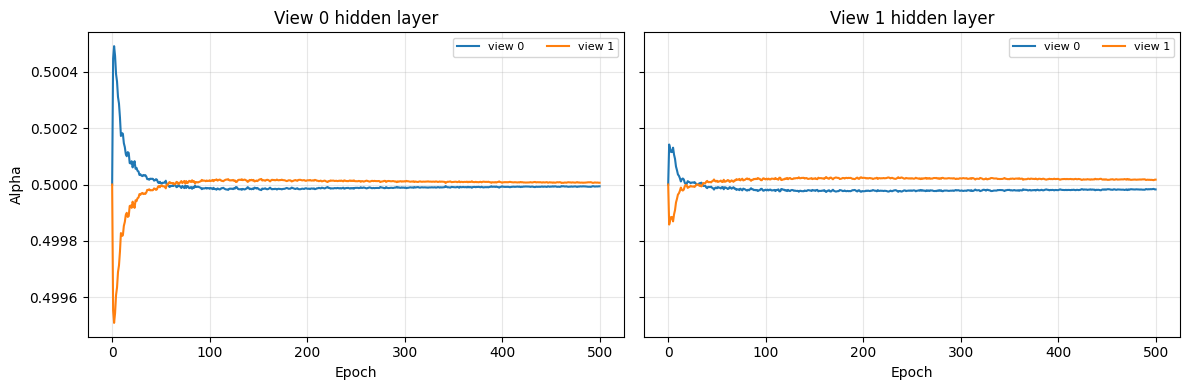

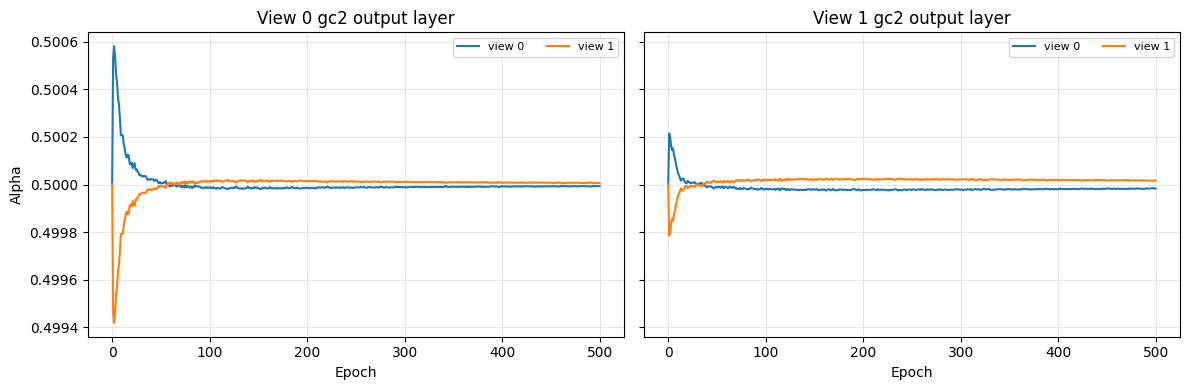

In [43]:
plot_laplacian(num_epochs, n_view, gc1_hist, gc2_hist)

In [44]:
# Print final alphas
for v in range(n_view):
    print(f"View-net {v}:")
    print("  gc1 alpha:", nets[v].gc1.alpha)
    print("  gc2 alpha:", nets[v].gc2.alpha)


View-net 0:
  gc1 alpha: [0.49999369 0.50000631]
  gc2 alpha: [0.49999372 0.50000628]
View-net 1:
  gc1 alpha: [0.49998267 0.50001733]
  gc2 alpha: [0.49998277 0.50001723]


In [45]:
def eval_metrics(log_probs, labels, idx):
    with torch.no_grad():
        preds = log_probs[idx].argmax(dim=1).cpu().numpy()
        y_true = labels[idx].cpu().numpy()

    cm = confusion_matrix(y_true, preds)
    acc = accuracy_score(y_true, preds)
    f1_macro = f1_score(y_true, preds, average="macro")

    return cm, acc, f1_macro

In [46]:
def plot_confusion_matrix(cm, class_names=None, normalize=False, cmap="GnBu"):
    if normalize:
        cm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title("Confusion Matrix" + (" (normalized)" if normalize else ""))
    plt.colorbar()
    tick_marks = np.arange(cm.shape[0])
    if class_names is None:
        class_names = ["Neutral", "Sadness", "Anger", "Happiness", "Calmness"]
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

In [47]:
out_sum = None
for v in range(n_view):
    out_v = nets[v](feats[v])
    out_sum = out_v if out_sum is None else (out_sum + out_v)

Acc: 0.7833333333333333 F1-macro: 0.775231901976088


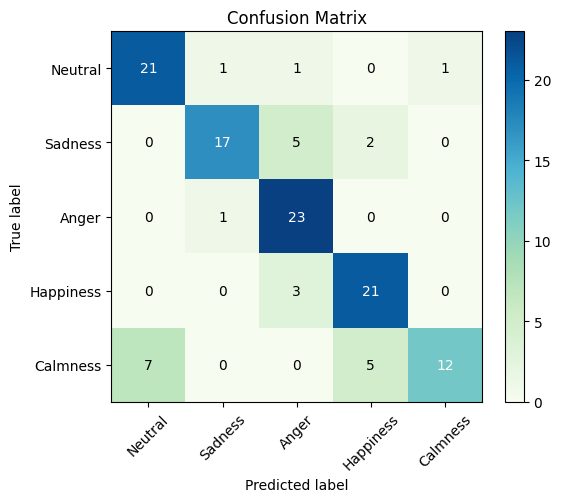

In [48]:
cm, acc, f1m = eval_metrics(out_sum, labels, test_idx)
print("Acc:", acc, "F1-macro:", f1m)
plot_confusion_matrix(cm, normalize=False)

In [34]:
def plot_view_tsne(X, y, title):
    Z = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)
    plt.figure(figsize=(5,5))
    for c in np.unique(y):
        plt.scatter(Z[y==c, 0], Z[y==c, 1], s=8, label=str(c))
    plt.title(title)
    plt.legend(markerscale=2)
    plt.tight_layout()
    plt.show()


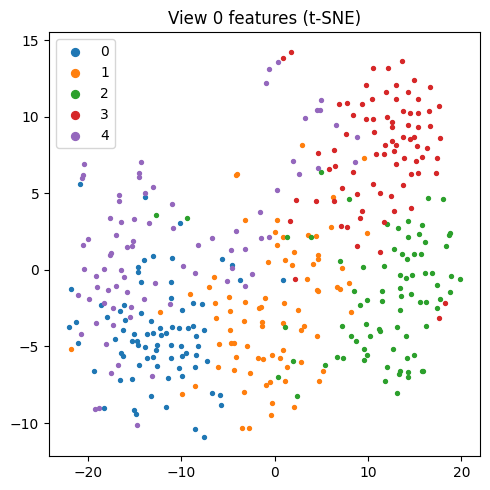

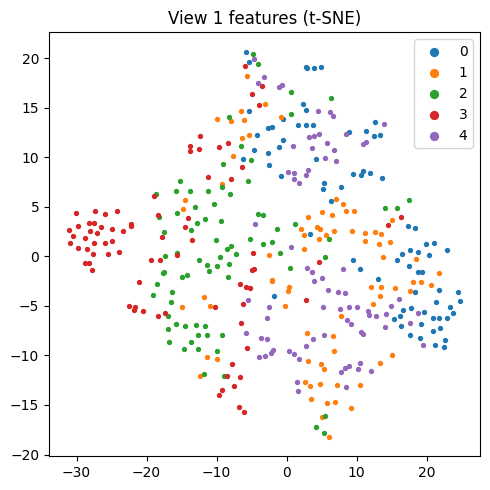

In [35]:
plot_view_tsne(X0, y, "View 0 features (t-SNE)")
plot_view_tsne(X1, y, "View 1 features (t-SNE)")